<a href="https://colab.research.google.com/github/Ab11d/OnlineStoreSalesAnalysis/blob/main/OnlineStoreAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [4]:
sales_df = pd.read_excel("sales.xlsx")

In [6]:
sales_df.head()

,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount
0,ORD0001,2026-03-20,Rahul,Hyderabad,Grocery,Coffee,6,476,0
1,ORD0002,2026-02-08,Sara,Kochi,Grocery,Rice Bag,8,1317,15
2,ORD0003,2026-03-25,Rahul,Kochi,Electronics,Laptop,2,52795,15
3,ORD0004,2026-06-20,Arjun,Calicut,Electronics,Phone,5,27289,15
4,ORD0005,2026-06-06,John,Kochi,Clothing,Jacket,3,3178,25


In [7]:
sales_df.tail()

,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount
195,ORD0196,2026-01-03,Diya,Mumbai,Electronics,Headphones,6,2661,10
196,ORD0197,2026-04-06,Nikhil,Bangalore,Clothing,T-Shirt,6,878,25
197,ORD0198,2026-04-11,Aman,Chennai,Electronics,Smartwatch,8,7620,30
198,ORD0199,2026-06-25,Aman,Delhi,Electronics,Phone,7,23525,15
199,ORD0200,2026-01-17,John,Chennai,Grocery,Milk Pack,1,55,20


In [8]:
print("Number of rows:", sales_df.shape[0])
print("Number of columns:", sales_df.shape[1])

Number of rows: 200
Number of columns: 9


In [9]:
print("Column names:")
print(sales_df.columns.tolist())

Column names:
['Order_ID', 'Date', 'Customer', 'City', 'Category', 'Product', 'Quantity', 'Price', 'Discount']


In [10]:
print("Data types:")
print(sales_df.dtypes)

Data types:
Order_ID    object
Date        object
Customer    object
City        object
Category    object
Product     object
Quantity     int64
Price        int64
Discount     int64
dtype: object


In [11]:
print("Missing values in each column:")
print(sales_df.isnull().sum())

Missing values in each column:
Order_ID    0
Date        0
Customer    0
City        0
Category    0
Product     0
Quantity    0
Price       0
Discount    0
dtype: int64


In [12]:
duplicate_count = sales_df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

sales_df[sales_df.duplicated()]

Number of duplicate records: 0


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount


In [13]:
sales_df.describe()

,Quantity,Price,Discount
count,200.000000,200.000000,200.00000
mean,4.480000,9210.810000,13.87500
std,2.221322,15851.411768,10.32679
min,1.000000,55.000000,0.00000
25%,3.000000,858.500000,5.00000
50%,4.000000,1805.000000,15.00000
75%,6.000000,7395.000000,25.00000
max,8.000000,59850.000000,30.00000


In [14]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"])

In [15]:
sales_df["Total Price"] = sales_df["Quantity"] * sales_df["Price"]

In [16]:
sales_df["Discount Amount"] = (
    sales_df["Total Price"] * sales_df["Discount"] / 100
)

In [17]:
sales_df["Final Amount"] = (
    sales_df["Total Price"] - sales_df["Discount Amount"]
)

In [18]:
sales_df["Month"] = sales_df["Date"].dt.month_name()

In [19]:
sales_df.head()

,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
0,ORD0001,2026-03-20,Rahul,Hyderabad,Grocery,Coffee,6,476,0,2856,0.00,2856.00,March
1,ORD0002,2026-02-08,Sara,Kochi,Grocery,Rice Bag,8,1317,15,10536,1580.40,8955.60,February
2,ORD0003,2026-03-25,Rahul,Kochi,Electronics,Laptop,2,52795,15,105590,15838.50,89751.50,March
3,ORD0004,2026-06-20,Arjun,Calicut,Electronics,Phone,5,27289,15,136445,20466.75,115978.25,June
4,ORD0005,2026-06-06,John,Kochi,Clothing,Jacket,3,3178,25,9534,2383.50,7150.50,June


In [22]:
# Part 4 – Data Analysis

# 1. Total revenue generated
total_revenue = sales_df["Final Amount"].sum()

print(f"1. Total Revenue: ₹{total_revenue:,.2f}")


# 2. Total number of orders
total_orders = sales_df["Order_ID"].nunique()

print(f"2. Total Orders: {total_orders}")


# 3. Number of unique customers
unique_customers = sales_df["Customer"].nunique()

print(f"3. Unique Customers: {unique_customers}")


# 4. Product with the highest revenue
product_revenue = sales_df.groupby("Product")["Final Amount"].sum()

highest_revenue_product = product_revenue.idxmax()
highest_product_revenue = product_revenue.max()

print(
    f"4. Highest Revenue Product: {highest_revenue_product} "
    f"(₹{highest_product_revenue:,.2f})"
)


# 5. Product with the highest quantity sold
product_quantity = sales_df.groupby("Product")["Quantity"].sum()

highest_quantity_product = product_quantity.idxmax()
highest_quantity = product_quantity.max()

print(
    f"5. Highest Quantity Product: {highest_quantity_product} "
    f"({highest_quantity} units)"
)


# 6. Category with the highest revenue
category_revenue = sales_df.groupby("Category")["Final Amount"].sum()

highest_revenue_category = category_revenue.idxmax()
highest_category_revenue = category_revenue.max()

print(
    f"6. Highest Revenue Category: {highest_revenue_category} "
    f"(₹{highest_category_revenue:,.2f})"
)


# 7. City with the highest revenue
city_revenue = sales_df.groupby("City")["Final Amount"].sum()

highest_revenue_city = city_revenue.idxmax()
highest_city_revenue = city_revenue.max()

print(
    f"7. Highest Revenue City: {highest_revenue_city} "
    f"(₹{highest_city_revenue:,.2f})"
)


# 8. Month with the highest sales
monthly_revenue = sales_df.groupby("Month")["Final Amount"].sum()

highest_sales_month = monthly_revenue.idxmax()
highest_month_revenue = monthly_revenue.max()

print(
    f"8. Highest Sales Month: {highest_sales_month} "
    f"(₹{highest_month_revenue:,.2f})"
)


# 9. Average order value
average_order_value = total_revenue / total_orders

print(f"9. Average Order Value: ₹{average_order_value:,.2f}")


# 10. Order with the highest final amount
highest_order_index = sales_df["Final Amount"].idxmax()
highest_order = sales_df.loc[highest_order_index]

print(
    f"10. Highest Order: {highest_order['Order_ID']} "
    f"(₹{highest_order['Final Amount']:,.2f})"
)

display(highest_order)

1. Total Revenue: ₹6,891,254.05
2. Total Orders: 200
3. Unique Customers: 15
4. Highest Revenue Product: Laptop (₹3,282,565.35)
5. Highest Quantity Product: Phone (103 units)
6. Highest Revenue Category: Electronics (₹6,118,067.35)
7. Highest Revenue City: Calicut (₹1,542,166.45)
8. Highest Sales Month: June (₹1,524,157.85)
9. Average Order Value: ₹34,456.27
10. Highest Order: ORD0194 (₹317,426.55)


,193
Order_ID,ORD0194
Date,2026-04-13 00:00:00
Customer,Anu
City,Calicut
Category,Electronics
Product,Laptop
Quantity,7
Price,53349
Discount,15
Total Price,373443


In [23]:
# Part 5 – Grouping and Aggregation

# 1. Revenue by Category
revenue_by_category = (
    sales_df.groupby("Category")["Final Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Category:")
display(revenue_by_category)


# 2. Revenue by City
revenue_by_city = (
    sales_df.groupby("City")["Final Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\nRevenue by City:")
display(revenue_by_city)


# 3. Revenue by Month
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June"
]

revenue_by_month = (
    sales_df.groupby("Month")["Final Amount"]
    .sum()
    .reindex(month_order)
)

print("\nRevenue by Month:")
display(revenue_by_month)


# 4. Average Discount by Category
average_discount_by_category = (
    sales_df.groupby("Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("\nAverage Discount by Category:")
display(average_discount_by_category)


# 5. Average Quantity Sold for Each Product
average_quantity_by_product = (
    sales_df.groupby("Product")["Quantity"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("\nAverage Quantity Sold for Each Product:")
display(average_quantity_by_product)

Revenue by Category:


,Final Amount
Category,
Electronics,6118067.35
Clothing,563139.20
Grocery,210047.50



Revenue by City:


,Final Amount
City,
Calicut,1542166.45
Mumbai,1170524.35
Chennai,1085625.60
Trivandrum,1030973.80
Hyderabad,763920.15
Delhi,471290.50
Bangalore,453497.25
Kochi,373255.95



Revenue by Month:


,Final Amount
Month,
January,883225.15
February,1252307.20
March,1133391.45
April,1267436.75
May,830735.65
June,1524157.85



Average Discount by Category:


,Discount
Category,
Electronics,15.08
Clothing,13.71
Grocery,12.92



Average Quantity Sold for Each Product:


,Quantity
Product,
Smartwatch,5.17
Jeans,5.07
Coffee,4.83
Shoes,4.73
Jacket,4.71
Rice Bag,4.68
Phone,4.48
Laptop,4.47
Headphones,4.29


In [25]:
# Part 6 – Filtering

# 1. Orders with Final Amount greater than ₹20,000
high_value_orders = sales_df[
    sales_df["Final Amount"] > 20000
]

print("1. Final Amount greater than ₹20,000")
print("Number of orders:", len(high_value_orders))
display(high_value_orders)


# 2. Orders with Discount greater than 20%
high_discount_orders = sales_df[
    sales_df["Discount"] > 20
]

print("\n2. Discount greater than 20%")
print("Number of orders:", len(high_discount_orders))
display(high_discount_orders)


# 3. Electronics category only
electronics_orders = sales_df[
    sales_df["Category"] == "Electronics"
]

print("\n3. Electronics category orders")
print("Number of orders:", len(electronics_orders))
display(electronics_orders)


# 4. Orders placed in January
january_orders = sales_df[
    sales_df["Month"] == "January"
]

print("\n4. Orders placed in January")
print("Number of orders:", len(january_orders))
display(january_orders)


# 5. Orders with Quantity greater than 5
large_quantity_orders = sales_df[
    sales_df["Quantity"] > 5
]

print("\n5. Quantity greater than 5")
print("Number of orders:", len(large_quantity_orders))
display(large_quantity_orders)

1. Final Amount greater than ₹20,000
Number of orders: 56


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
2,ORD0003,2026-03-25,Rahul,Kochi,Electronics,Laptop,2,52795,15,105590,15838.50,89751.50,March
3,ORD0004,2026-06-20,Arjun,Calicut,Electronics,Phone,5,27289,15,136445,20466.75,115978.25,June
5,ORD0006,2026-01-08,Vivek,Delhi,Electronics,Phone,6,27444,0,164664,0.00,164664.00,January
8,ORD0009,2026-02-10,Fatima,Delhi,Electronics,Smartwatch,7,7286,5,51002,2550.10,48451.90,February
9,ORD0010,2026-03-29,Fatima,Hyderabad,Electronics,Phone,5,25486,15,127430,19114.50,108315.50,March
20,ORD0021,2026-05-29,Fatima,Kochi,Electronics,Smartwatch,3,8182,15,24546,3681.90,20864.10,May
21,ORD0022,2026-02-11,Aisha,Chennai,Electronics,Smartwatch,8,8626,10,69008,6900.80,62107.20,February
22,ORD0023,2026-02-27,Nikhil,Chennai,Electronics,Phone,3,24728,5,74184,3709.20,70474.80,February
25,ORD0026,2026-02-20,Vivek,Mumbai,Electronics,Laptop,8,49531,30,396248,118874.40,277373.60,February
26,ORD0027,2026-06-01,Fatima,Calicut,Electronics,Laptop,2,58571,15,117142,17571.30,99570.70,June



2. Discount greater than 20%
Number of orders: 52


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
4,ORD0005,2026-06-06,John,Kochi,Clothing,Jacket,3,3178,25,9534,2383.50,7150.50,June
6,ORD0007,2026-05-07,Nikhil,Hyderabad,Grocery,Coffee,4,431,30,1724,517.20,1206.80,May
24,ORD0025,2026-02-10,Meera,Mumbai,Clothing,Jeans,7,1822,25,12754,3188.50,9565.50,February
25,ORD0026,2026-02-20,Vivek,Mumbai,Electronics,Laptop,8,49531,30,396248,118874.40,277373.60,February
34,ORD0035,2026-02-18,Neha,Delhi,Grocery,Coffee,7,471,25,3297,824.25,2472.75,February
38,ORD0039,2026-06-04,Sara,Trivandrum,Electronics,Laptop,6,52069,30,312414,93724.20,218689.80,June
42,ORD0043,2026-05-04,Priya,Hyderabad,Electronics,Phone,5,22652,30,113260,33978.00,79282.00,May
44,ORD0045,2026-06-04,Arjun,Chennai,Electronics,Laptop,4,56741,25,226964,56741.00,170223.00,June
45,ORD0046,2026-03-24,Priya,Kochi,Grocery,Cooking Oil,7,895,25,6265,1566.25,4698.75,March
49,ORD0050,2026-06-10,Diya,Trivandrum,Electronics,Phone,6,22974,30,137844,41353.20,96490.80,June



3. Electronics category orders
Number of orders: 66


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
2,ORD0003,2026-03-25,Rahul,Kochi,Electronics,Laptop,2,52795,15,105590,15838.50,89751.50,March
3,ORD0004,2026-06-20,Arjun,Calicut,Electronics,Phone,5,27289,15,136445,20466.75,115978.25,June
5,ORD0006,2026-01-08,Vivek,Delhi,Electronics,Phone,6,27444,0,164664,0.00,164664.00,January
8,ORD0009,2026-02-10,Fatima,Delhi,Electronics,Smartwatch,7,7286,5,51002,2550.10,48451.90,February
9,ORD0010,2026-03-29,Fatima,Hyderabad,Electronics,Phone,5,25486,15,127430,19114.50,108315.50,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,ORD0193,2026-04-01,Priya,Chennai,Electronics,Smartwatch,5,7320,30,36600,10980.00,25620.00,April
193,ORD0194,2026-04-13,Anu,Calicut,Electronics,Laptop,7,53349,15,373443,56016.45,317426.55,April
195,ORD0196,2026-01-03,Diya,Mumbai,Electronics,Headphones,6,2661,10,15966,1596.60,14369.40,January
197,ORD0198,2026-04-11,Aman,Chennai,Electronics,Smartwatch,8,7620,30,60960,18288.00,42672.00,April



4. Orders placed in January
Number of orders: 37


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
5,ORD0006,2026-01-08,Vivek,Delhi,Electronics,Phone,6,27444,0,164664,0.00,164664.00,January
11,ORD0012,2026-01-25,Diya,Kochi,Clothing,Jeans,8,1731,15,13848,2077.20,11770.80,January
18,ORD0019,2026-01-18,Priya,Mumbai,Grocery,Cooking Oil,4,931,0,3724,0.00,3724.00,January
19,ORD0020,2026-01-23,Aisha,Bangalore,Clothing,Shoes,1,4367,20,4367,873.40,3493.60,January
31,ORD0032,2026-01-01,Sara,Hyderabad,Electronics,Headphones,5,2655,10,13275,1327.50,11947.50,January
35,ORD0036,2026-01-01,Anu,Chennai,Electronics,Phone,6,25698,0,154188,0.00,154188.00,January
36,ORD0037,2026-01-03,Neha,Mumbai,Grocery,Coffee,4,428,0,1712,0.00,1712.00,January
48,ORD0049,2026-01-19,Anu,Trivandrum,Grocery,Cooking Oil,2,896,15,1792,268.80,1523.20,January
50,ORD0051,2026-01-17,Meera,Mumbai,Electronics,Headphones,1,2468,0,2468,0.00,2468.00,January
52,ORD0053,2026-01-23,Diya,Delhi,Electronics,Headphones,7,2612,0,18284,0.00,18284.00,January



5. Quantity greater than 5
Number of orders: 72


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
0,ORD0001,2026-03-20,Rahul,Hyderabad,Grocery,Coffee,6,476,0,2856,0.00,2856.00,March
1,ORD0002,2026-02-08,Sara,Kochi,Grocery,Rice Bag,8,1317,15,10536,1580.40,8955.60,February
5,ORD0006,2026-01-08,Vivek,Delhi,Electronics,Phone,6,27444,0,164664,0.00,164664.00,January
7,ORD0008,2026-04-24,Arjun,Chennai,Clothing,Jeans,7,1643,5,11501,575.05,10925.95,April
8,ORD0009,2026-02-10,Fatima,Delhi,Electronics,Smartwatch,7,7286,5,51002,2550.10,48451.90,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,ORD0194,2026-04-13,Anu,Calicut,Electronics,Laptop,7,53349,15,373443,56016.45,317426.55,April
195,ORD0196,2026-01-03,Diya,Mumbai,Electronics,Headphones,6,2661,10,15966,1596.60,14369.40,January
196,ORD0197,2026-04-06,Nikhil,Bangalore,Clothing,T-Shirt,6,878,25,5268,1317.00,3951.00,April
197,ORD0198,2026-04-11,Aman,Chennai,Electronics,Smartwatch,8,7620,30,60960,18288.00,42672.00,April


In [26]:
# Part 7 – Sorting

# 1. Sort by highest Final Amount
highest_final_amount = sales_df.sort_values(
    by="Final Amount",
    ascending=False
)

print("Highest Final Amount:")
display(highest_final_amount)


# 2. Sort by lowest Final Amount
lowest_final_amount = sales_df.sort_values(
    by="Final Amount",
    ascending=True
)

print("\nLowest Final Amount:")
display(lowest_final_amount)


# 3. Sort by highest Quantity sold
highest_quantity = sales_df.sort_values(
    by="Quantity",
    ascending=False
)

print("\nHighest Quantity Sold:")
display(highest_quantity)


# 4. Sort by highest Discount
highest_discount = sales_df.sort_values(
    by="Discount",
    ascending=False
)

print("\nHighest Discount:")
display(highest_discount)

Highest Final Amount:


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
193,ORD0194,2026-04-13,Anu,Calicut,Electronics,Laptop,7,53349,15,373443,56016.45,317426.55,April
110,ORD0111,2026-04-27,Rahul,Chennai,Electronics,Laptop,6,57497,15,344982,51747.30,293234.70,April
123,ORD0124,2026-05-22,Fatima,Trivandrum,Electronics,Laptop,6,59850,20,359100,71820.00,287280.00,May
25,ORD0026,2026-02-20,Vivek,Mumbai,Electronics,Laptop,8,49531,30,396248,118874.40,277373.60,February
57,ORD0058,2026-02-17,Rahul,Mumbai,Electronics,Laptop,7,56127,30,392889,117866.70,275022.30,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,ORD0134,2026-06-22,Rahul,Kochi,Grocery,Milk Pack,4,64,30,256,76.80,179.20,June
43,ORD0044,2026-04-06,Meera,Delhi,Grocery,Milk Pack,3,56,5,168,8.40,159.60,April
73,ORD0074,2026-03-29,Arjun,Mumbai,Grocery,Milk Pack,3,60,30,180,54.00,126.00,March
152,ORD0153,2026-06-01,Kiran,Chennai,Grocery,Milk Pack,1,62,25,62,15.50,46.50,June



Lowest Final Amount:


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
199,ORD0200,2026-01-17,John,Chennai,Grocery,Milk Pack,1,55,20,55,11.00,44.00,January
152,ORD0153,2026-06-01,Kiran,Chennai,Grocery,Milk Pack,1,62,25,62,15.50,46.50,June
73,ORD0074,2026-03-29,Arjun,Mumbai,Grocery,Milk Pack,3,60,30,180,54.00,126.00,March
43,ORD0044,2026-04-06,Meera,Delhi,Grocery,Milk Pack,3,56,5,168,8.40,159.60,April
133,ORD0134,2026-06-22,Rahul,Kochi,Grocery,Milk Pack,4,64,30,256,76.80,179.20,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,ORD0058,2026-02-17,Rahul,Mumbai,Electronics,Laptop,7,56127,30,392889,117866.70,275022.30,February
25,ORD0026,2026-02-20,Vivek,Mumbai,Electronics,Laptop,8,49531,30,396248,118874.40,277373.60,February
123,ORD0124,2026-05-22,Fatima,Trivandrum,Electronics,Laptop,6,59850,20,359100,71820.00,287280.00,May
110,ORD0111,2026-04-27,Rahul,Chennai,Electronics,Laptop,6,57497,15,344982,51747.30,293234.70,April



Highest Quantity Sold:


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
1,ORD0002,2026-02-08,Sara,Kochi,Grocery,Rice Bag,8,1317,15,10536,1580.40,8955.60,February
55,ORD0056,2026-06-06,Aisha,Bangalore,Grocery,Rice Bag,8,1086,0,8688,0.00,8688.00,June
62,ORD0063,2026-03-18,Aisha,Kochi,Grocery,Rice Bag,8,1208,0,9664,0.00,9664.00,March
33,ORD0034,2026-03-05,Priya,Mumbai,Electronics,Phone,8,27095,20,216760,43352.00,173408.00,March
25,ORD0026,2026-02-20,Vivek,Mumbai,Electronics,Laptop,8,49531,30,396248,118874.40,277373.60,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,ORD0180,2026-05-10,Kiran,Trivandrum,Clothing,T-Shirt,1,853,5,853,42.65,810.35,May
183,ORD0184,2026-03-26,Vivek,Kochi,Clothing,T-Shirt,1,857,15,857,128.55,728.45,March
180,ORD0181,2026-02-05,Neha,Chennai,Electronics,Laptop,1,50471,30,50471,15141.30,35329.70,February
185,ORD0186,2026-05-03,John,Trivandrum,Electronics,Headphones,1,2270,15,2270,340.50,1929.50,May



Highest Discount:


,Order_ID,Date,Customer,City,Category,Product,Quantity,Price,Discount,Total Price,Discount Amount,Final Amount,Month
6,ORD0007,2026-05-07,Nikhil,Hyderabad,Grocery,Coffee,4,431,30,1724,517.2,1206.8,May
49,ORD0050,2026-06-10,Diya,Trivandrum,Electronics,Phone,6,22974,30,137844,41353.2,96490.8,June
70,ORD0071,2026-06-06,Nikhil,Kochi,Grocery,Cooking Oil,2,875,30,1750,525.0,1225.0,June
57,ORD0058,2026-02-17,Rahul,Mumbai,Electronics,Laptop,7,56127,30,392889,117866.7,275022.3,February
67,ORD0068,2026-06-09,Sara,Delhi,Clothing,Jacket,2,3508,30,7016,2104.8,4911.2,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,ORD0173,2026-06-10,Diya,Mumbai,Electronics,Smartwatch,2,8475,0,16950,0.0,16950.0,June
178,ORD0179,2026-04-24,Aman,Delhi,Clothing,Jeans,3,1811,0,5433,0.0,5433.0,April
168,ORD0169,2026-04-10,Aman,Kochi,Electronics,Laptop,3,53585,0,160755,0.0,160755.0,April
191,ORD0192,2026-04-08,John,Hyderabad,Grocery,Cooking Oil,5,852,0,4260,0.0,4260.0,April


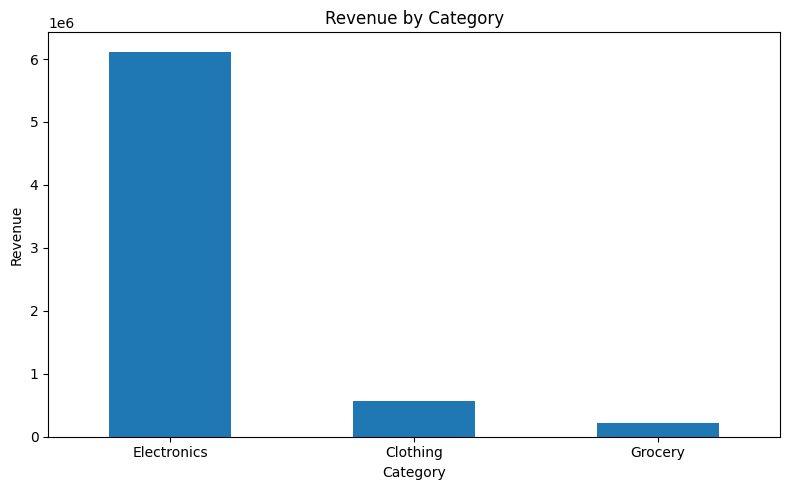

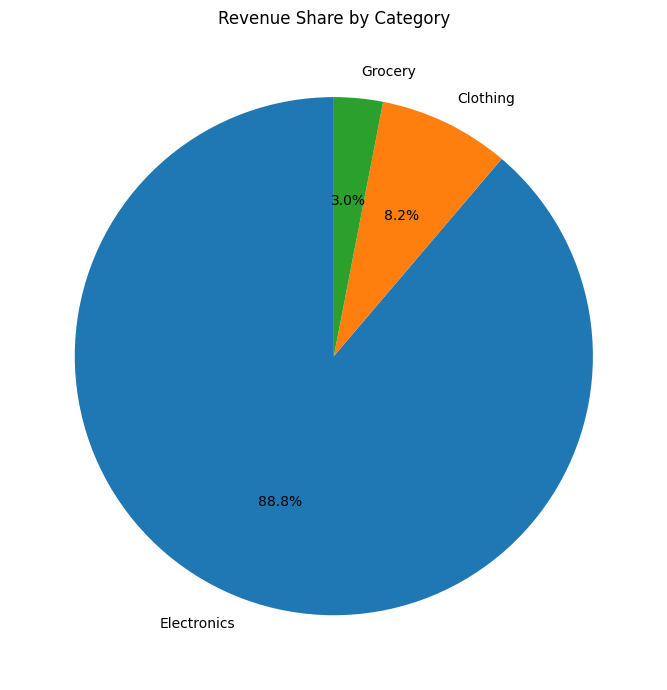

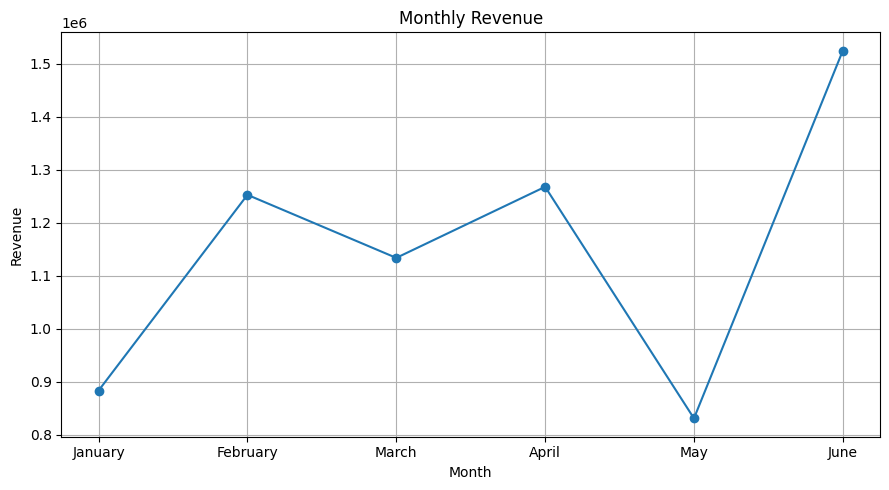

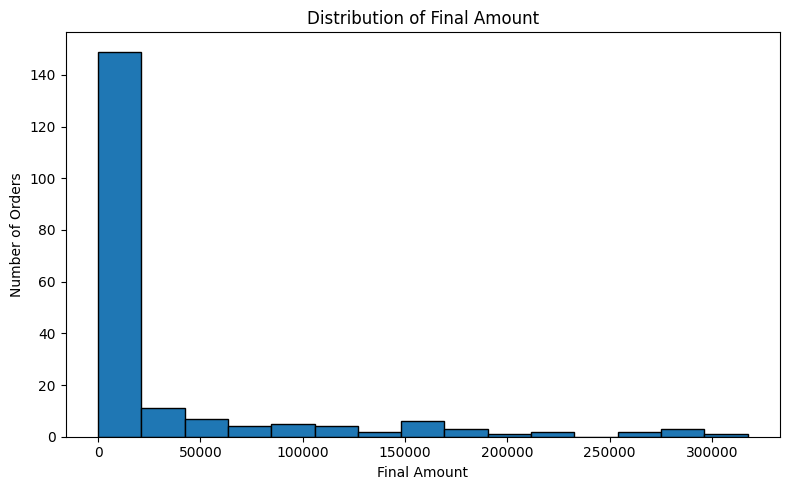

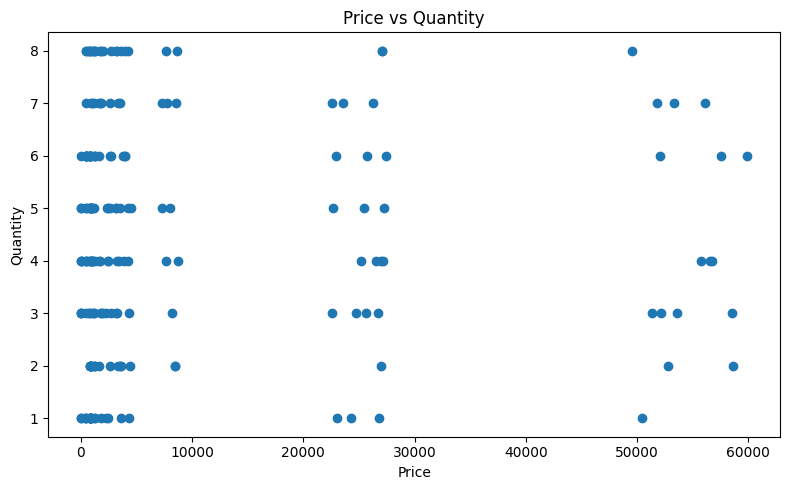

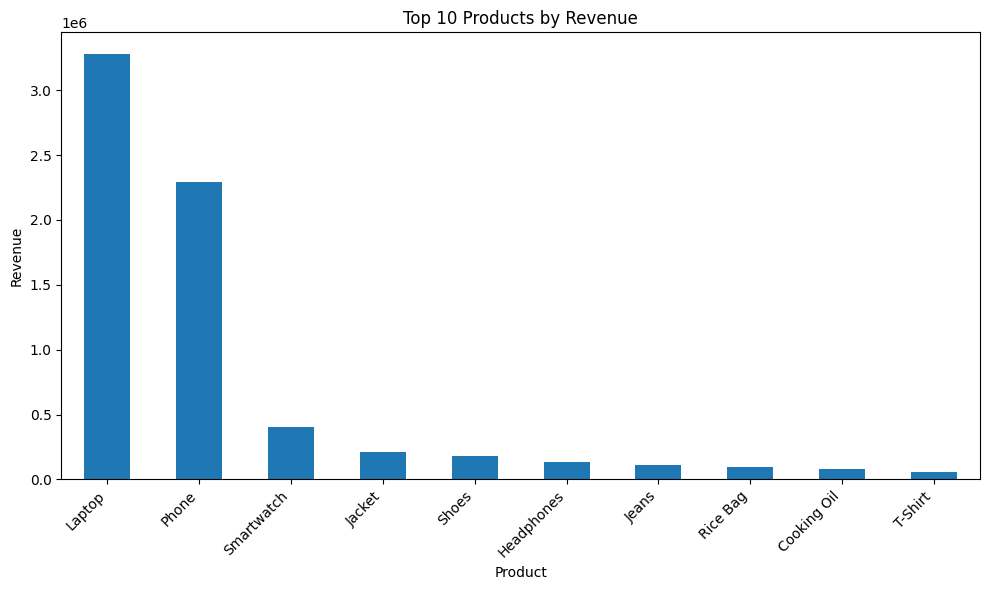

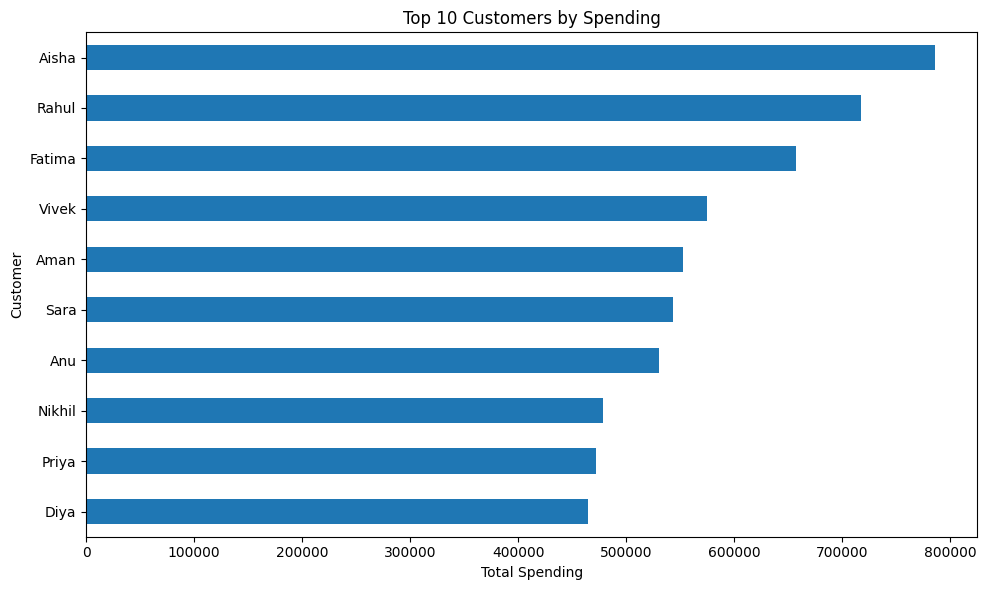

In [27]:
# Part 8 – Data Visualization

import matplotlib.pyplot as plt


# 1. Bar Chart – Revenue by Category
revenue_by_category = (
    sales_df.groupby("Category")["Final Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
revenue_by_category.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 2. Pie Chart – Revenue Share by Category
plt.figure(figsize=(7, 7))
revenue_by_category.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Share by Category")
plt.ylabel("")
plt.tight_layout()
plt.show()


# 3. Line Chart – Monthly Revenue
monthly_revenue = (
    sales_df.groupby(sales_df["Date"].dt.month)["Final Amount"]
    .sum()
    .sort_index()
)

month_names = (
    sales_df.groupby(sales_df["Date"].dt.month)["Month"]
    .first()
    .sort_index()
)

monthly_revenue.index = month_names.values

plt.figure(figsize=(9, 5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()


# 4. Histogram – Distribution of Final Amount
plt.figure(figsize=(8, 5))
plt.hist(
    sales_df["Final Amount"],
    bins=15,
    edgecolor="black"
)
plt.title("Distribution of Final Amount")
plt.xlabel("Final Amount")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


# 5. Scatter Plot – Price vs Quantity
plt.figure(figsize=(8, 5))
plt.scatter(
    sales_df["Price"],
    sales_df["Quantity"]
)
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


# 6. Bar Chart – Top 10 Products by Revenue
top_10_products = (
    sales_df.groupby("Product")["Final Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_10_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 7. Horizontal Bar Chart – Top 10 Customers by Spending
top_10_customers = (
    sales_df.groupby("Customer")["Final Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
top_10_customers.plot(kind="barh")
plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

Customer Spending and Segments:


,Customer,Total Customer Spending,Customer Segment
0,Aisha,785709.60,Platinum
12,Rahul,717173.60,Platinum
5,Fatima,657199.25,Platinum
14,Vivek,574570.75,Gold
1,Aman,552396.95,Gold
13,Sara,543603.30,Gold
2,Anu,530705.60,Gold
10,Nikhil,478713.05,Silver
11,Priya,471647.60,Silver
4,Diya,464742.45,Silver



Number of Customers in Each Segment:


,count
Customer Segment,
Platinum,3
Gold,4
Silver,5
Bronze,3


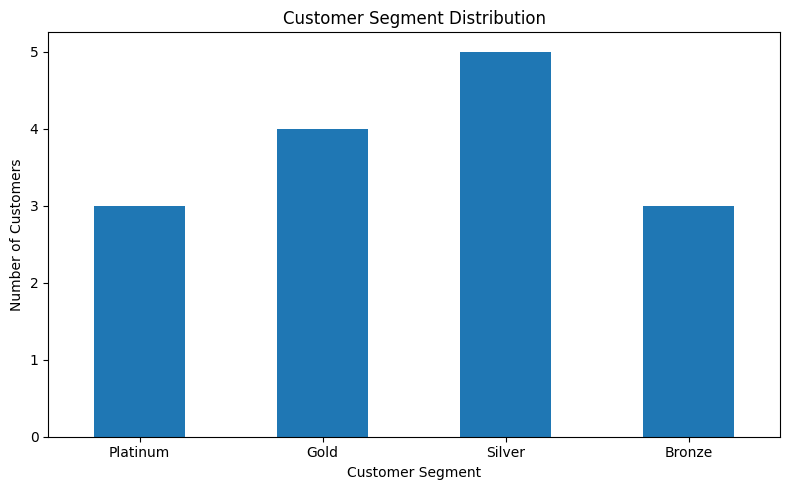


Top 5 Platinum Customers:


,Customer,Total Customer Spending,Customer Segment
0,Aisha,785709.60,Platinum
12,Rahul,717173.60,Platinum
5,Fatima,657199.25,Platinum


In [30]:
# Part 9 – Bonus Challenge: Customer Segmentation

# Calculate the total amount spent by each customer
customer_spending = (
    sales_df.groupby("Customer")["Final Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Final Amount": "Total Customer Spending"})
)


# Function to assign a customer segment
def assign_customer_segment(spending):
    if spending > 600000:
        return "Platinum"
    elif spending >= 500000:
        return "Gold"
    elif spending >= 300000:
        return "Silver"
    else:
        return "Bronze"


# Create the Customer Segment column
customer_spending["Customer Segment"] = (
    customer_spending["Total Customer Spending"]
    .apply(assign_customer_segment)
)


# Add the Customer Segment column to the original dataset
customer_segment_map = customer_spending.set_index(
    "Customer"
)["Customer Segment"]

sales_df["Customer Segment"] = sales_df["Customer"].map(
    customer_segment_map
)


# Display customer spending and segments
print("Customer Spending and Segments:")
display(
    customer_spending.sort_values(
        by="Total Customer Spending",
        ascending=False
    )
)


# Count the number of customers in each segment
segment_order = [
    "Platinum",
    "Gold",
    "Silver",
    "Bronze"
]

segment_counts = (
    customer_spending["Customer Segment"]
    .value_counts()
    .reindex(segment_order, fill_value=0)
)

print("\nNumber of Customers in Each Segment:")
display(segment_counts)


# Bar chart showing the segment distribution
plt.figure(figsize=(8, 5))
segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Identify the Top 5 Platinum customers
top_5_platinum_customers = (
    customer_spending[
        customer_spending["Customer Segment"] == "Platinum"
    ]
    .sort_values(
        by="Total Customer Spending",
        ascending=False
    )
    .head(5)
)

print("\nTop 5 Platinum Customers:")
display(top_5_platinum_customers)